In [1]:
import warnings

from keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import matthews_corrcoef
from sklearn.model_selection import train_test_split
from tqdm import tqdm, trange
import torch
from torch.utils.data import (
    TensorDataset, 
    DataLoader, 
    RandomSampler, 
    SequentialSampler
)
from transformers import (
    AdamW,
    BertConfig,
    BertModel,
    BertForSequenceClassification,
    BertTokenizer,
    get_linear_schedule_with_warmup,
)


In [2]:
warnings.filterwarnings('ignore')

In [15]:
BATCH_SIZE = 32
EPOCHS = 4
MAX_LEN = 128

In [4]:
DEVICE = (torch.device('mps') if torch.backends.mps.is_available()
          else torch.device('cpu'))
print(f'Training on device {DEVICE}')

Training on device mps


In [5]:
df = pd.read_csv('./echo_from_epikriz_corpus.csv')

df.shape

(6729, 2)

In [6]:
df.head(2)

,echo_from_epikriz,target
0,плахова клименко увеличен тонкие подвижные изм...,0.0
1,левое предсердие особенности увеличено левый ж...,0.0


In [7]:
sentences = df.echo_from_epikriz.values
sentences = ['[CLS] ' + str(sentence) + ' [SEP]' for sentence in sentences]
labels = df.target.values
tokenizer = BertTokenizer.from_pretrained(
    './rubert_cased_L-12_H-768_A-12_pt_v1', 
    do_lower_case=True
    )
tokenized_texts = [tokenizer.tokenize(str(sent)) for sent in sentences]

print ('Tokenize the first sentence:')
print (tokenized_texts[0])

Tokenize the first sentence:
['[CLS]', 'пла', '##хова', 'клим', '##енко', 'увеличен', 'тонкие', 'подвижные', 'изменен', 'дуга', 'перешеек', 'суж', '##ены', 'увеличены', 'расширены', 'изменен', 'д', '##м', '##ж', '##п', 'прит', '##очны', '##и', 'кровот', '##ок', 'ламин', '##арн', '##ы', '##и', 'заключ', 'д', '##м', '##ж', '##п', '[SEP]']


In [9]:
input_ids = [tokenizer.convert_tokens_to_ids(x) for x in tokenized_texts]

input_ids = pad_sequences(
    input_ids, 
    maxlen=MAX_LEN, 
    dtype='long', 
    truncating='post', padding='post'
    )
attention_masks = []

for seq in input_ids:
  seq_mask = [float(i>0) for i in seq]
  attention_masks.append(seq_mask)

In [10]:
train_inputs, validation_inputs, train_labels, validation_labels = train_test_split(
    input_ids, 
    labels, 
    random_state=2018, 
    test_size=0.1
    )
train_masks, validation_masks, _, _ = train_test_split(
    attention_masks, 
    input_ids,
    random_state=2018, 
    test_size=0.1
    )

In [11]:
train_inputs = torch.tensor(train_inputs)
validation_inputs = torch.tensor(validation_inputs)
train_labels = torch.tensor(train_labels)
validation_labels = torch.tensor(validation_labels)
train_masks = torch.tensor(train_masks)
validation_masks = torch.tensor(validation_masks)

In [12]:
train_data = TensorDataset(
    train_inputs, 
    train_masks, 
    train_labels
    )
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(
    train_data, 
    sampler=train_sampler, 
    batch_size=BATCH_SIZE
    )

validation_data = TensorDataset(
    validation_inputs, 
    validation_masks, 
    validation_labels
    )
validation_sampler = SequentialSampler(validation_data)
validation_dataloader = DataLoader(
    validation_data, 
    sampler=validation_sampler, 
    batch_size=BATCH_SIZE
    )

In [13]:
configuration = BertConfig()
model = BertModel(configuration)
configuration = model.config

print(configuration)

BertConfig {
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.43.2",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



In [18]:
model = BertForSequenceClassification.from_pretrained(
    './rubert_cased_L-12_H-768_A-12_pt_v1', 
    num_labels=2
    ).to(DEVICE)

model

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ./rubert_cased_L-12_H-768_A-12_pt_v1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

In [14]:
param_optimizer = list(model.named_parameters())
no_decay = ['bias', 'LayerNorm.weight']
# Separate the `weight` parameters from the `bias` parameters. 
# - For the `weight` parameters, this specifies a 'weight_decay_rate' of 0.01. 
# - For the `bias` parameters, the 'weight_decay_rate' is 0.0. 
optimizer_grouped_parameters = [
    # Filter for all parameters which *don't* include 'bias', 'gamma', 'beta'.
    {'params': [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)],
     'weight_decay_rate': 0.1},
     
    # Filter for parameters which *do* include those.
    {'params': [p for n, p in param_optimizer if any(nd in n for nd in no_decay)],
     'weight_decay_rate': 0.0}
]

In [ ]:
optimizer = AdamW(
    optimizer_grouped_parameters,
    lr=2e-5, # args.learning_rate - default is 5e-5, our notebook had 2e-5
    eps=1e-8 # args.adam_epsilon  - default is 1e-8.
)
# Total number of training steps is number of batches * number of epochs.
# `train_dataloader` contains batched data so `len(train_dataloader)` gives 
# us the number of batches.
total_steps = len(train_dataloader) * EPOCHS

# Create the learning rate scheduler.
scheduler = get_linear_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=0, # Default value in run_glue.py
    num_training_steps=total_steps
    )

/Users/alexeyfilichkin/opt/anaconda3/lib/python3.12/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [21]:
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

In [ ]:
t = [] 

# Store our loss and accuracy for plotting
train_loss_set = []

# trange is a tqdm wrapper around the normal python range
for _ in trange(EPOCHS, desc='Epoch'):
  
  # Set our model to training mode (as opposed to evaluation mode)
  model.train()
  
  # Tracking variables
  tr_loss = 0
  nb_tr_examples, nb_tr_steps = 0, 0
  
  # Train the data for one epoch
  for step, batch in enumerate(train_dataloader):
    # Add batch to GPU
    batch = tuple(t.to(torch.float32).to(DEVICE) for t in batch)
    # Unpack the inputs from our dataloader
    b_input_ids, b_input_mask, b_labels = batch
    # Clear out the gradients (by default they accumulate)
    optimizer.zero_grad()
    b_input_ids = b_input_ids.type(torch.LongTensor).to(DEVICE)
    b_input_mask = b_input_mask.type(torch.LongTensor).to(DEVICE)
    b_labels = b_labels.type(torch.LongTensor).to(DEVICE)

    # Forward pass
    outputs = model(
      b_input_ids, 
      token_type_ids=None, 
      attention_mask=b_input_mask, 
      labels=b_labels
      )
    loss = outputs['loss']
    train_loss_set.append(loss.item())    
    # Backward pass
    loss.backward()
    # Update parameters and take a step using the computed gradient
    optimizer.step()
    # Update the learning rate.
    scheduler.step()
    # Update tracking variables
    tr_loss += loss.item()
    nb_tr_examples += b_input_ids.size(0)
    nb_tr_steps += 1

  print('Train loss: {}'.format(tr_loss/nb_tr_steps))
  
  # Validation
  model.eval()

  # Tracking variables 
  eval_loss, eval_accuracy = 0, 0
  nb_eval_steps, nb_eval_examples = 0, 0

  # Evaluate data for one epoch
  for batch in validation_dataloader:
    # Add batch to GPU
    batch = tuple(t.to(torch.float32).to(DEVICE) for t in batch)
    # Unpack the inputs from our dataloader
    b_input_ids, b_input_mask, b_labels = batch
    b_input_ids = b_input_ids.type(torch.LongTensor).to(DEVICE)
    b_input_mask = b_input_mask.type(torch.LongTensor).to(DEVICE)
    b_labels = b_labels.type(torch.LongTensor).to(DEVICE)
    # Telling the model not to compute or store gradients, saving memory and speeding up validation
    with torch.no_grad():
      # Forward pass, calculate logit predictions
      logits = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)
    
    # Move logits and labels to CPU
    logits = logits['logits'].detach().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()

    tmp_eval_accuracy = flat_accuracy(logits, label_ids)
    
    eval_accuracy += tmp_eval_accuracy
    nb_eval_steps += 1

  print('Validation Accuracy: {}'.format(eval_accuracy/nb_eval_steps))

Epoch:   0%|          | 0/4 [00:00<?, ?it/s]

Train loss: 0.2422650870131819


Epoch:  25%|██▌       | 1/4 [03:01<09:03, 181.17s/it]

Validation Accuracy: 0.8821022727272727
Train loss: 0.21769261009206897


Epoch:  50%|█████     | 2/4 [06:00<06:00, 180.23s/it]

Validation Accuracy: 0.8821022727272727
Train loss: 0.19385775892358076


Epoch:  75%|███████▌  | 3/4 [08:59<02:59, 179.49s/it]

Validation Accuracy: 0.8821022727272727
Train loss: 0.1684105501265118


Epoch: 100%|██████████| 4/4 [11:58<00:00, 179.55s/it]

Validation Accuracy: 0.8778409090909091


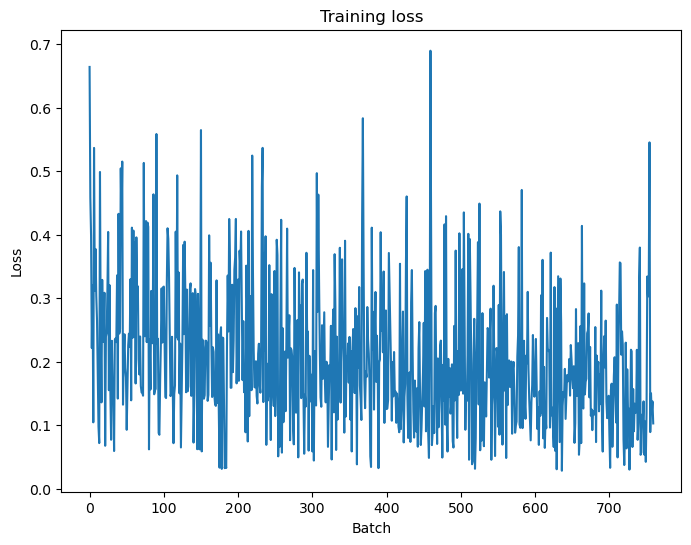

In [23]:
plt.figure(figsize=(8, 6))
plt.title('Training loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.plot(train_loss_set)
plt.show()

In [25]:
df = pd.read_csv('./echo_from_epikriz_corpus.csv')

sentences = df.echo_from_epikriz.values

sentences = ['[CLS] ' + str(sentence) + ' [SEP]' for sentence in sentences]
labels = df.target.values

tokenized_texts = [tokenizer.tokenize(str(sent)) for sent in sentences]

input_ids = [tokenizer.convert_tokens_to_ids(x) for x in tokenized_texts]

input_ids = pad_sequences(
    input_ids, 
    maxlen=MAX_LEN, 
    dtype='long', 
    truncating='post', padding='post'
    )

attention_masks = []

for seq in input_ids:
  seq_mask = [float(i>0) for i in seq]
  attention_masks.append(seq_mask)

In [ ]:
prediction_inputs = torch.tensor(input_ids)
prediction_masks = torch.tensor(attention_masks)
prediction_labels = torch.tensor(labels)

prediction_data = TensorDataset(
    prediction_inputs, 
    prediction_masks, 
    prediction_labels
    )
prediction_sampler = SequentialSampler(prediction_data)
prediction_dataloader = DataLoader(
    prediction_data, 
    sampler=prediction_sampler, 
    batch_size=BATCH_SIZE
    )

In [28]:
model.eval()

predictions , true_labels = [], []

for batch in prediction_dataloader:
  # Add batch to GPU
  batch = tuple(t.to(torch.float32).to(DEVICE) for t in batch)
  # Unpack the inputs from our dataloader
  b_input_ids, b_input_mask, b_labels = batch
  b_input_ids = b_input_ids.type(torch.LongTensor).to(DEVICE)
  b_input_mask = b_input_mask.type(torch.LongTensor).to(DEVICE)
  b_labels = b_labels.type(torch.LongTensor).to(DEVICE)
  # Telling the model not to compute or store gradients, saving memory and speeding up prediction
  with torch.no_grad():
    # Forward pass, calculate logit predictions
    logits = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)

  # Move logits and labels to CPU
  logits = logits['logits'].detach().cpu().numpy()
  label_ids = b_labels.to('cpu').numpy()
  
  # Store predictions and true labels
  predictions.append(logits)
  true_labels.append(label_ids)

In [ ]:
matthews_set = []

for i in range(len(true_labels)):
  matthews = matthews_corrcoef(true_labels[i],
                 np.argmax(predictions[i], axis=1).flatten())
  matthews_set.append(matthews)

In [ ]:
flat_predictions = [item for sublist in predictions for item in sublist]
flat_predictions = np.argmax(flat_predictions, axis=1).flatten()
flat_true_labels = [item for sublist in true_labels for item in sublist]

matthews_corrcoef(flat_true_labels, flat_predictions)

0.21395608339558186

In [24]:
torch.save(model.state_dict(), './fine/operations_model.bin')